In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import pandas as pd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [ ]:
phase_pallette = ['#e41a1c', '#377eb8', "#4daf4a"]
config = read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/2008_tracking/01_02.yaml")

In [4]:
tracking_data = xr.open_mfdataset('/wolke_scratch/dnikolo/Glac_visualization/20100501.0015_20100515.0000/pixel_path_tracking/20100501.0015_20100515.0000/cloud*.nc', combine='by_coords')

In [5]:
glac_df = pd.read_parquet('/wolke_scratch/dnikolo/Final_results/2010_glac_04.parquet') #pd.read_parquet('/wolke_scratch/dnikolo/Glac_visualization/Analysis_results/Agg_03_Glaciations.parquet')
lim_glac_df = glac_df[(glac_df["track_start_time"] > "2010-05-01 00:15:00") & (glac_df["track_start_time"] < "2010-05-15 00:00:00") & (glac_df["pole"]=="np") & (glac_df["min_temp"]==-30)]

In [6]:
sample_glac = lim_glac_df.sample(10,random_state=1)
sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
sample_glac["track_end_time"] = sample_glac["track_start_time"]+ sample_glac["track_length"]


In [7]:
aux_file = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)

In [8]:
lat_mat = aux_file["lat"].values[0, :, :]
lon_mat = aux_file["lon"].values[0, :, :]
# lat_mat[np.isnan(lat_mat)] = np.inf
# lon_mat[np.isnan(lon_mat)] = 0

In [9]:
sample_glac.tracknumber

55931    4640
56140    6566
55588    1652
55593    1689
55843    3844
55442     357
55481     711
55467     565
56134    6521
55410      28
Name: tracknumber, dtype: int64

In [10]:
print(tracking_data["tracknumber"].max().values)

8043.0


In [11]:
# for _, cloud in sample_glac.iterrows():
# 1) Pull out the cloud sampled glaciation

# print(t)
# for time_ind in range(feat_vals.shape[0]-1):
#     current_image = feat_vals[time_ind]
#     x , y = np.where(current_image==cloud["tracknumber"])
#     if len(x) ==0:
#         print(time_ind,feat_vals.shape[0])
#         # print(x)
        
#     plt.imshow(current_image[x.min():x.max(), y.min():y.max()])


In [12]:
sample_glac["avg_size[px]"]

55931    23.550000
56140    14.307692
55588    50.454545
55593    20.642857
55843     8.333333
55442     6.250000
55481    12.600000
55467    15.722222
56134     6.600000
55410    51.096774
Name: avg_size[px], dtype: float64

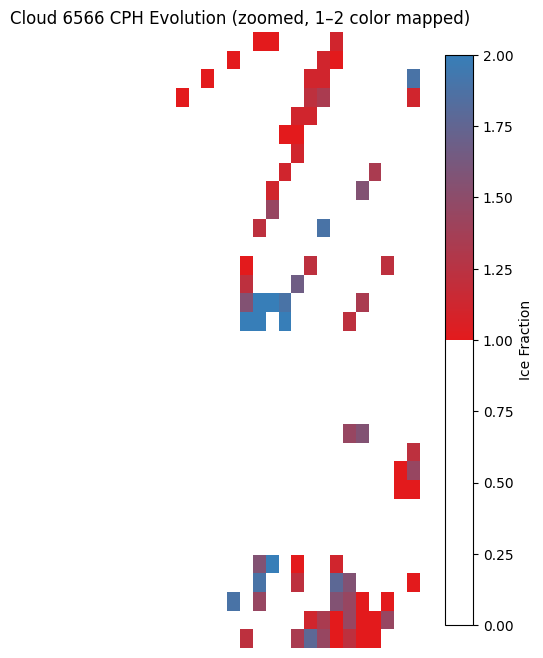

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

cloud = sample_glac.iloc[1]

# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])



import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors as mcolors
from IPython.display import HTML

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# Build masked_cph so that only the current cloud’s pixels have their CPH values:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# Find the global bounding box of non-NaN pixels across all frames
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# Crop masked_cph to that box
# cropped = masked_cph[:, y_min : y_max + 1, x_min : x_max + 1]
frame_width = 10
cropped = cph_vals[:, y_min - frame_width : y_max + 1 +frame_width, x_min-frame_width : x_max + 1+frame_width]
cropped_masked = masked_cph[:, y_min - frame_width : y_max + 1 +frame_width, x_min-frame_width : x_max + 1+frame_width]

# Create a custom colormap: white for values < 1; gradient from red to blue for 1–2
phase_palette = ['#e41a1c', '#377eb8']
cmap_phase = mcolors.LinearSegmentedColormap.from_list(
    'phase_cmap',
    [
        (0.0, "white"),
        (0.4999, "white"),
        (0.5, phase_palette[0]),
        (1.0, phase_palette[1])
    ]
)

# Now animate the cropped region with the new colormap:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    cropped[0],
    vmin=0, 
    vmax=2, 
    cmap=cmap_phase,
    interpolation="none",
    extent=(x_min, x_max, y_max, y_min)  # keep original pixel coordinates
)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Ice Fraction")

ax.set_title(f"Cloud {track_id} CPH Evolution (zoomed, 1–2 color mapped)")
ax.axis("off")

def update(frame):
    im.set_data(cropped[frame])
    ax.set_xlabel(f"Time step: {frame}")
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=300,   # ms between frames
    blit=True
)

# Display inline in Jupyter:
HTML(anim.to_html5_video())




In [ ]:
for _, cloud in sample_glac.iterrows():
    # 1) Pull out the cloud sampled glaciation
    # cloud = sample_glac.iloc[9]

    # 2) Grab its start/end times
    t0 = cloud.track_start_time
    t1 = cloud.glaciation_end_time 

    # 4) Make sure your Dataset’s time coordinate is in datetime64:
    #    (optional sanity check)
    tracking_data['time'] = tracking_data.indexes['time']
    # 5) Slice the Dataset in time and select the right track:
    # sub = tracking_data.sel(
    #     time=slice(t0, t1)
    # )
    sub = tracking_data.sel(
        time=slice(t0, t1)
    )
    # 6) Pull out the feature_number variable
    feat_vals = sub['tracknumber'].values
    cph_vals = sub["cph_filtered"].values
    initial_mat = feat_vals[0]
    end_mat = feat_vals[-1]
    # print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
    size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
    t, x,y = np.where(feat_vals==cloud["tracknumber"])


    print(t)
    # for time_ind in range(feat_vals.shape[0]-1):
    #     current_image = feat_vals[time_ind]
    #     x , y = np.where(current_image==cloud["tracknumber"])
    #     if len(x) ==0:
    #         print(time_ind,feat_vals.shape[0])
    #         # print(x)
            
    #     plt.imshow(current_image[x.min():x.max(), y.min():y.max()])

    
    # print(np.count_nonzero( np.isnan(feat_vals)))
    # # print(cloud.track_id, cloud.glaciation_start_time, cloud.glaciation_end_time, cloud.lat_hist[0], cloud.lon_hist[0])
    # diff_mat = np.abs((lat_mat - cloud.lat_hist[0])) + np.abs((lon_mat - cloud.lon_hist[0]))
    # untransformed_init_idx = np.where(diff_mat==np.nanmin(diff_mat))
    # cloud_init_idx = (np.array([int(untransformed_init_idx[0][0]/3)]),np.array([int(untransformed_init_idx[1][0]/3)]))
    # print(cloud_init_idx, untransformed_init_idx)
    # region = feat_vals[0][cloud_init_idx[0][0]-3:cloud_init_idx[0][0]+4, cloud_init_idx[1][0]-3:cloud_init_idx[1][0]+4]
    # print(region)
    # print(np.unique(region))

[0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9
 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]
[ 0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4  4  4  4
  4  5  5  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  6
  6  6  6  6  6  6  6  6  7  7  7  7  7  7  7  7  7  7  7  7  7  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  9  9  9
  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9 10 10 10
 

In [ ]:
plt.imshow( region)
plt.colorbar()

NameError: name 'region' is not defined

In [ ]:
diff_mat

array([[ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       [ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       [ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       ...,
       [ 49.09272817, 133.26361587, 131.98847453, ..., 157.93725236,
         49.09272817,  49.09272817],
       [ 49.09272817, 132.38805242, 131.45515588, ..., 157.06179686,
         49.09272817,  49.09272817],
       [132.90893869, 131.77152705, 130.99614073, ..., 156.4453059 ,
        157.58262605,  49.09272817]])

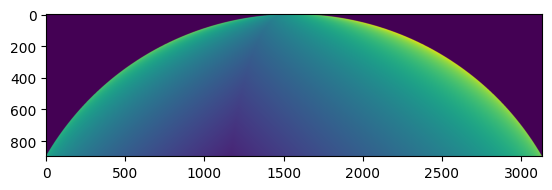

In [ ]:
plt.imshow(diff_mat)
plt.show()

In [ ]:
np.argmin((lat_mat - cloud.lat_hist[0]) + (lon_mat - cloud.lon_hist[0]),keepdims=True)


array([[2769578]])

In [ ]:
feat_vals.max()

2278.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# For the demo, generate dummy feat_vals if not already defined
# Remove or replace this line with your real feat_vals array.
# feat_vals = np.random.rand(50, 10, 10)  

fig, ax = plt.subplots()
# Initialize the image with zeros and set vmin/vmax
im = ax.imshow(np.zeros_like(feat_vals[0]), vmin=1,vmax=168, aspect='equal',cmap='viridis')
ax.set_title("Feature Number Heatmap")

def init():
    im.set_data(np.zeros_like(feat_vals[0]))
    return (im,)

def animate(i):
    im.set_data(feat_vals[i])
    return (im,)

# Create the animation
anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=feat_vals.shape[0], interval=200, blit=True
)

plt.close(fig)  # Prevent duplicate static plot display
HTML(anim.to_jshtml())


Error in callback <function _draw_all_if_interactive at 0x7f3fa699fd80> (for post_execute):


AttributeError: AxesImage.set() got an unexpected keyword argument 'square'

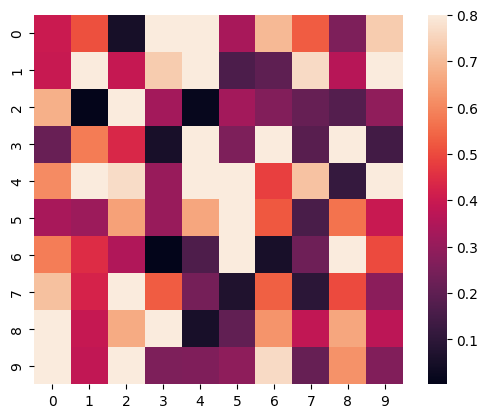

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import animation
# %matplotlib ipympl
fig = plt.figure()
data = np.random.rand(10, 10)
sns.heatmap(data, vmax=.8, square=True)

def init():
    plt.imshow(np.zeros(feat_vals.shape[1:]), vmax=.8, square=True, cbar=False)

def animate(i):
    # data = np.random.rand(10, 10)
    plt.imshow(feat_vals[i,:,:], vmax=.8, square=True, cbar=False)

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=feat_vals.shape[0], repeat = False)

In [ ]:
import numpy as np
import pandas as pd

# 1. get your start
start = pd.to_datetime(sample_glac.iloc[0]["glaciation_start_time"])

# 2. (optional) strip any timezone info so the dtypes match
start = start.tz_localize(None)

# 3. pull out the numpy array of times
time_arr = tracking_data.time.values  # this is an array of numpy.datetime64

# 4a. for an *exact* lookup (may still KeyError if not present):
try:
    idx_exact = tracking_data.time.to_index().get_loc(start)
except KeyError:
    idx_exact = None

# 4b. for the *nearest* match:
idx_nearest = np.argmin(np.abs(time_arr - np.datetime64(start)))

# 5. choose whichever index you want
index_to_use = idx_exact if idx_exact is not None else idx_nearest

# 6. isel by that integer
feat = tracking_data["feature_number"].isel(time=index_to_use)


In [ ]:
print(idx_nearest)

395


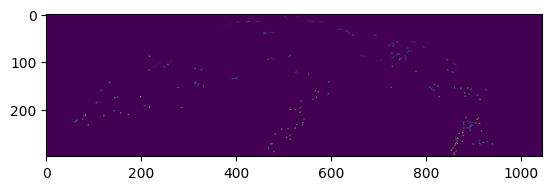

In [ ]:
plt.imshow(feat)

In [ ]:
tracking_data["feature_number"].isel(time=)

SyntaxError: invalid syntax (1001145380.py, line 1)

In [ ]:
sample_glac.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'is_large_pix_cloud', 'is_cot_valid_cloud',
       'is_ctp_valid_cloud', 'is_liq', 'is_mix', 'is_ice', 'max_water_frac',
       'max_ice_fraction', 'avg_size[km]', 'max_size[km]', 'min_size[km]',
       'avg_size[px]', 'max_size[px]', 'min_size[px]', 'track_start_time',
       'track_length', 'avg_cot', 'avg_ctp', 'glaciation_start_time',
       'glaciation_end_time', 'avg_lat', 'avg_lon', 'start_ice_fraction',
       'end_ice_fraction', 'ice_frac_hist', 'cot_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_nan_frac_hist', 'lat_hist', 'lon_hist', 'size_hist_km',
       'min_temp', 'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]'],
      dtype='object')

Text(0.5, 1.0, 'Sample Glacier Ice Fraction Over Time')

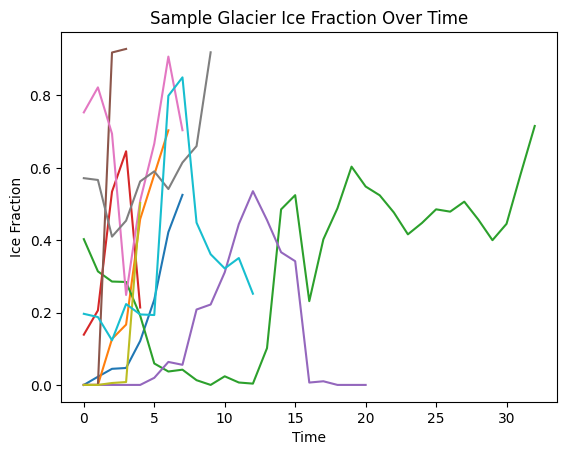

In [ ]:
for glac_if_hist in sample_glac["ice_frac_hist"].values:
    plt.plot(glac_if_hist)
    
    # plt.legend()
    # plt.show()
# plt.plot(a.values[0])
plt.xlabel("Time")
plt.ylabel("Ice Fraction")
plt.title("Sample Glacier Ice Fraction Over Time")